# **Module 2 - Neural Encoding Models**
    Neural encoding models. The Action Potential. Postsinaptic potentials. The Spike Triggered average.
#### **The Action Potential**
Action Potentials (PAs) code information via the frequency on which they are triggered. A p(t) sequence can be characterised for when have the PAs been triggered (ti) in a time interval T. Similarly they can be represented as a delta Dirac function [^1]:
> ==$p(t)=\sum_{i=1}^nδ(t −ti)$

This function can be reinterpreted as a series of integrals throughout time. In this case, the neural response to a function (t) would be represented as[^2]:
> ==$\sum_{i=1}^nh(t −ti)=\int_0^Tdτ h(τ)ρ(t −τ)$

This conversion (sumatory) of PAs can be turned (via the integral) to a continuous signal with a variable amplitude. For the frequency modeling of PAs probabilistic models can be used (the probability of ta PA to be triggered in a determined time) [^3]. Scripted in Python, the model would look like this:

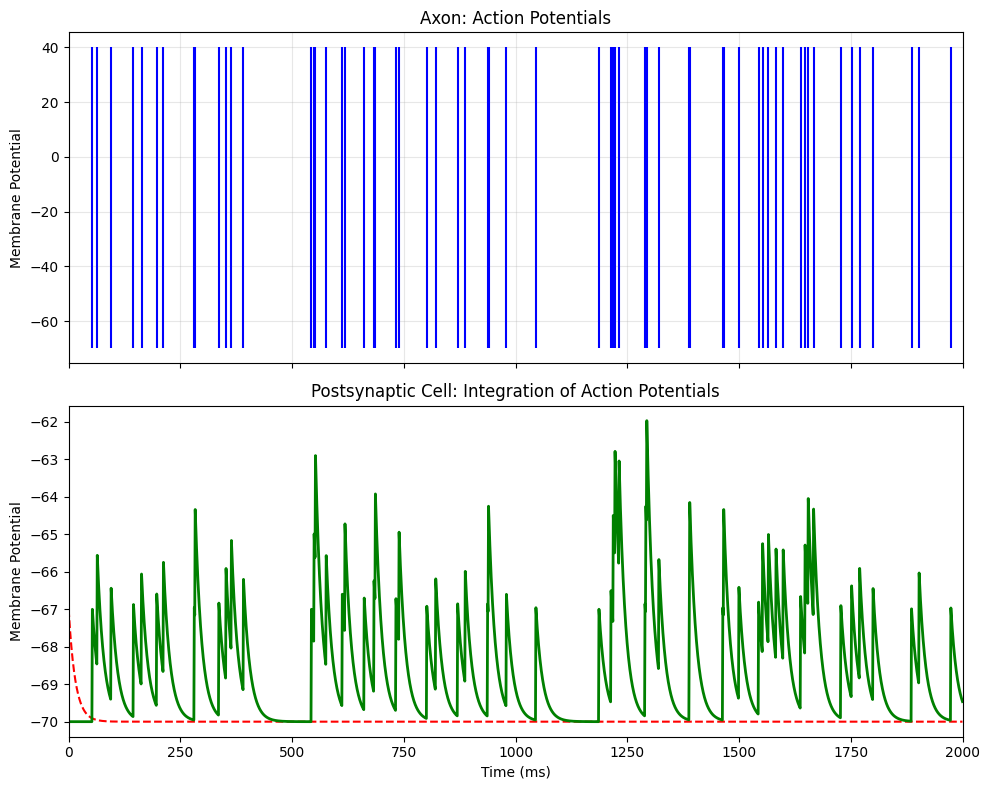

In [ ]:
#1.1) SPIKE COUNTING:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
tau= 15 #ms, time constant, property from the neuron itself
Vrep=-70 #Membrane Potential in mV
neural_response_amplitude=3 # this is the change that a PA will provoke in the next cell
p=0.035 #% probability that a PA wil be triggered each ms
t=np.linspace(0, 2000, 2000) #2000 trials in 2000ms (absolute refractory period of 1ms)
spike = np.random.choice([0, 1], size=len(t), p=[1 - p, p])
model_response= np.exp(-t/tau)
model_response= model_response*neural_response_amplitude # defines the properties of the postsynaptic cell, appears in red in the graph

neural_response=convolve(spike, model_response, mode="full")[:len(t)] #this is what the integral would do in the mathematical model
real_response= Vrep + neural_response

#GRAPHIC REPRESENTATION:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Spikes:
spikes_in_mv = np.where(spike == 1, 40, Vrep)
ax1.vlines(t, Vrep, spikes_in_mv, color="blue", linewidth=1.5)
ax1.set_title("Axon: Action Potentials")
ax1.set_ylabel("Membrane Potential")
ax1.grid(True, alpha=0.3)

# Postsynaptic cell:
ax2.plot(t, Vrep+ model_response, linestyle="--", color="red")
ax2.plot(t, real_response, color="green", linewidth=2)
ax2.set_title("Postsynaptic Cell: Integration of Action Potentials")
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Membrane Potential")
ax2.set_xlim(0, 2000)  # simulation time

plt.tight_layout()
plt.show()

#### **Spike Triggered Average:**
Spike-triggered averaging is a method that relates PAs to the stimulus that evokes them. When doing trials with a neuron, we can observe when it triggers a PA and register ir. When a meaningful number of trials has been done, we can average the stimuli that triggered a response in the neuron. The **spike-triggered average (STA)** of a neuron can give important information about its nature and function. The STA assumes that the neuron only answers to one type of stimulus, the neuron behaves like a linear model (linear filter). Some examples would be neurons in the visual cortex that only trigger a response when light is oriented in a specific direction, or neurons that trigger a response when the given stimulus is a familiar face.
In the script below is a method to calculate the STA of a neuron given random noise as a stimulus. Here the STA doesn´t make much sense because the only criteria for this neuron to trigger a PA is that the stimulus must be above the given threshold. But when the script is tried with real data (such as the example given in the week 2 exam on the University of Washington Computational Neuroscience course), you can observe a more clear pattern. 

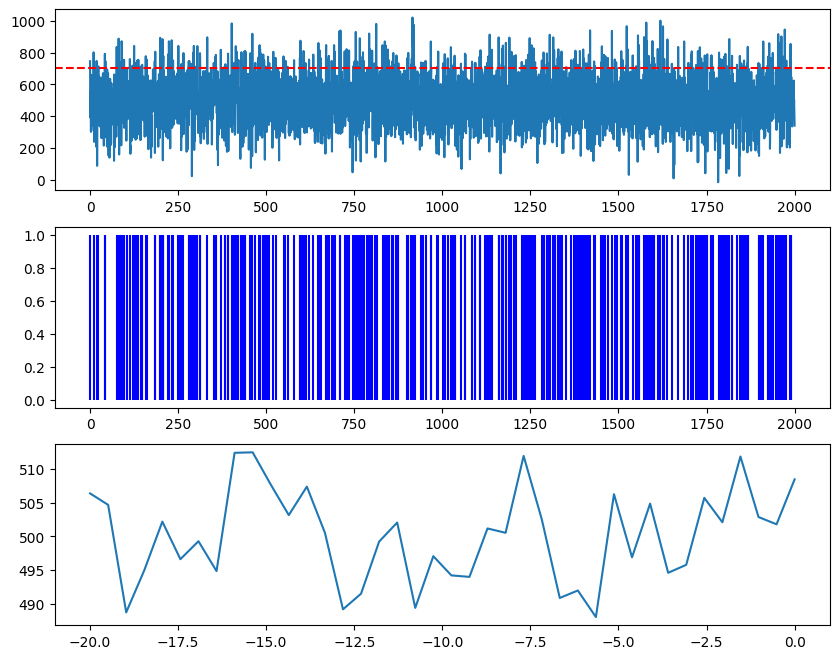

In [ ]:
#1.2) STA CALCULATION:
import numpy as np
import matplotlib.pyplot as plt
#for this example the stimuli will be random noise, but you can try the script with real data from the stimulus and response of a real neuron to see more clearly the STA calculation and representation


#Stimulus
t=np.linspace(0, 2000, 4000)
noise=np.random.normal(loc=500, scale=150, size=len(t)) 

#PA triggering
threshold= 700 #the stimuli must be above 700 to trigger a response in this neuron
spike = np.where(noise >= threshold, 1, 0)
 
#STA calculation
pa=np.where(spike==1)
pa_record=np.where(spike==1)[0]
noise_record=[]
for pa in pa_record: 
    if pa>=40:
        noise_window=noise[pa-40:pa]
        noise_record.append(noise_window)
noise_array = np.array(noise_record)
sta=np.mean(noise_array, axis=0)  
tiempo_sta = np.linspace(-20, 0, 40)


#GRAPHIC REPRESENTATION:
fig, (ax1, ax2,ax3) = plt.subplots(3, 1, figsize=(10, 8))

#Noise
ax1.plot(t,noise)
ax1.axhline(threshold,color="red", linestyle="--")

#Action Potentials
ax2.vlines(t, 0, spike, color="blue", linewidth=1.5)

#Spike-Triggered Average
ax3.plot(tiempo_sta,sta)

plt.show()

#### **Limitations of the STA: non-linear systems:**
As previously said, the STA assumes a linear relationship between the stimulus and the neural response, but in some cases neurons can answer to different stimuli, and when we calculate the STA those types of stimuli cancel themselves and the STA can be misleading. This is why non-linear models or filters exist.
Imagine we were representing all the different stimuli (such as the noise variable previously coded) as a collection of vectors or points in a space. The appearance of this space would be a "cloud" with all the points following a Gaussian distribution. The centre of this "cloud" is 0 (the mean for the noise). 
If we filtered the points that activated a neuron with a linear filter, the cloud would move its mean to the STA, but the variance would stay the same. If the neuron didn't have a linear filter, the mean would remain 0 (different stimuli that activate the neuron cancel themselves when calculating the STA) but the variance would change, there would be more points in the areas of the different stimuli that would activate the non-linear neuron.

![alt text](images/linear and non-linear filters.png)

To find the stimuli that activate a neuron with a non-linear filter, the STA can't be used. A more reliable method would be the **principal components analysis (PCA)**. What the PCA does is studying how the original noise cloud has been deformed towards an ellipsoid shape and finding the axis of this new cloud. The direction of the deformation is describedd by the **eigenvectors** whereas the magnitude is described by **eigenvalues**. While the STA and the analysis of linear models depend on te mean, the PCA and non-linear models analyze the variance, being able to decode the different stimuli that activate a neuron.

Here is a representation of a neuron with a non-linear filter as a Python Script.

Simulation completed, total number of spikes: 3974.


<>:64: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:64: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\carlo\AppData\Local\Temp\ipykernel_20188\952488267.py:64: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax1.set_ylabel("Variance ($\lambda$)")


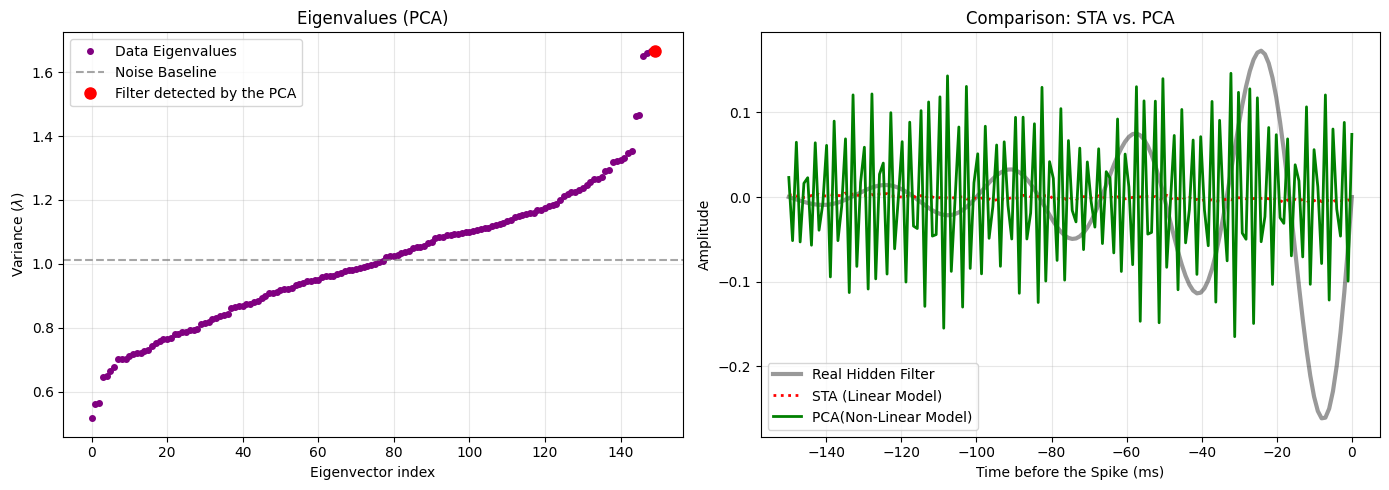

In [ ]:
#1.3) PCA:
import numpy as np
import matplotlib.pyplot as plt

t=np.linspace(0, 2000, 4000)

# Stimulus
stimulus = np.random.normal(0, 1, len(t)) #We set the mean to 0 to facilitate the PCA and the variance to 1. The noise follows a Gaussian disribution.
# Non-linear filter
ms_window = 150 # The neuron segments the time into 150ms windows, to which it applies individually the filter.
time_filter = np.linspace(-ms_window, 0, ms_window)
# The filter goes up and down fastly just before the spike, like a wave that oscillates and then turns down.
hidden_filter = np.sin(2 * np.pi * 0.03 * time_filter) * np.exp(time_filter / 40) 
# The sinusoidal component makes the neuron sensitive to certain frecuencies (imagine a neuron from the auditory system), whereas the exponential component applies the filter in each time window to process the stimulus correctly.
hidden_filter /= np.linalg.norm(hidden_filter) # We normalize the filter.

# For each ms, the stimulus is compared (convolution) to the filter, here is where the filtering occurs.
comparison = np.convolve(stimulus, hidden_filter[::-1], mode='same')
#We square the comparison. This generates the non-linearity (even symmetry). The neuron will trigger a spike with the same intensity no matter if the filter detects the original pattern or the inverted one.
firing_rate = 15 * (comparison ** 2) 

# Spikes are generated using a Poisson process based in the firing rate.
firing_prob = firing_rate * t
spikes = np.random.rand(len(t)) < firing_prob
spike_index = np.where(spikes == 1)[0]

print(f"Simulation completed, total number of spikes: {len(spike_index)}.")

# The noise windows are kept to do the STA and PCA.
noise_array = []   
for idx in spike_index:
    if idx >= ms_window:
        noise_array.append(stimulus[idx - ms_window : idx])
noise_array = np.array(noise_array)

# STA vs PCA:

# Calculating the filter with the STA.
sta = np.mean(noise_array, axis=0)

# Using the PCA to find the deformation of the variance.
matriz_centrada = noise_array - sta
cov_array = np.col = np.cov(matriz_centrada.T)

# We apply the PCA (Eigendecomposition)
autovalores, autovectores = np.linalg.eigh(cov_array)

# The component with the hisgher eigenvalue is selected
pca_filter = autovectores[:, -1]

# The PCA doesn´t know the original sign, it just sees the axis. If it´s inverted, we correct it.
if np.dot(pca_filter, hidden_filter) < 0:
    pca_filter = -pca_filter

# 5. Graphic Representation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: The Eigenvalue Specter demonstrates that there is a hidden filter.
ax1.plot(autovalores, 'o', color='purple', markersize=4, label='Data Eigenvalues')
ax1.axhline(np.mean(autovalores), color='gray', linestyle='--', alpha=0.7, label='Noise Baseline')
#  The last point is marked, it must stand out drastically upwards.
ax1.plot(len(autovalores)-1, autovalores[-1], 'ro', markersize=8, label='Filter detected by the PCA')
ax1.set_title("Eigenvalues (PCA)")
ax1.set_xlabel("Eigenvector index")
ax1.set_ylabel("Variance ($\lambda$)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graph 2: Comparison between the STA (failed) and the PCA (effective).
ax2.plot(time_filter, hidden_filter, label='Real Hidden Filter', color='black', linewidth=3, alpha=0.4)
ax2.plot(time_filter, sta, label='STA (Linear Model)', color='red', linestyle=':', linewidth=2)
ax2.plot(time_filter, pca_filter, label='PCA(Non-Linear Model)', color='green', linewidth=2)
ax2.set_title("Comparison: STA vs. PCA")
ax2.set_xlabel("Time before the Spike (ms)")
ax2.set_ylabel("Amplitude")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()  



##### **References:** 
Theoretical Neuroscience: Computational and Mathematical Modeling of Neural Systems - Peter Dayan, L. F. Abbott

##### **Notes:**
[^1]: Basically the function represent vertical lines in the indicated time of each PA. The coded information would be the sumatory of these PAs.

[^2]: [The Dirac Delta 'Function': How to model an impulse or infinite spike](https://www.youtube.com/watch?v=SxNVcCVj-3c&t=81s)

[^3]: Something similar to a Bernoulli model.